Imports torch and other packages

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import time
import numpy as np
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.cuda.manual_seed_all(seed)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4070 Laptop GPU


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cuda


Chargement des données de MNIST

In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)

#train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512)

Premier model: 784 en entre (1 pour chaque pixel: 28x28 → 784)
1 couche intermediaire
couche de sortie 10.
ReLu()

In [188]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

2e model: 784 en entre (1 pour chaque pixel: 28x28 → 784)
couche de sortie 10.
ReLu()

In [4]:
class SecondeMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

3e model: 784 en entre (1 pour chaque pixel: 28x28 → 784)
couche de sortie 10.
ReLu() + l'utilisation de             nn.BatchNorm1d(),

In [191]:
class ThirdMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

4e model: model intermediaire qui passe de 784 a 64, mais n'utilise plus le batchNorm1d

In [203]:
class FourthMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        return self.model(x)

Initialisation

In [5]:
#model =  ThirdMLP().to(device)
model =  SecondeMLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

Fonction d’évaluation

In [6]:
def evaluate(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

Training

In [7]:
start_time = time.time()
test_accuracy = 0
for epoch in range(10):

    model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()
    if (epoch % 2  == 0 or test_accuracy >= 0.955):
        test_accuracy = evaluate(model, test_loader)

    print(f"Epoch {epoch} - Accuracy: {test_accuracy}")

    if test_accuracy >= 0.97:
        print("Objectif atteint !")
        break

end_time = time.time()

print("Temps total :", end_time - start_time)
print(next(model.parameters()).device)

Epoch 0 - Accuracy: 0.9459
Epoch 1 - Accuracy: 0.9459
Epoch 2 - Accuracy: 0.9655
Epoch 3 - Accuracy: 0.9698
Epoch 4 - Accuracy: 0.9704
Objectif atteint !
Temps total : 15.318534851074219
cuda:0


Premier resultat Obtenue :
Epoch 0 - Accuracy: 0.9453
Epoch 1 - Accuracy: 0.9651
Epoch 2 - Accuracy: 0.9695
Epoch 3 - Accuracy: 0.9745
Objectif atteint !
Temps total : 14.942085266113281

test manuel

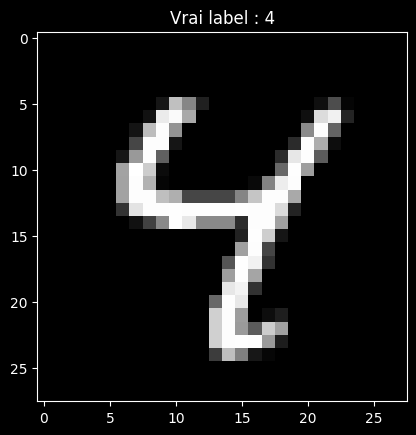

Prédiction du modèle : 4


In [8]:
import matplotlib.pyplot as plt

# prendre une image du test dataset
image, label = test_dataset[6]

# afficher l'image
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Vrai label : {label}")
plt.show()

# passer dans le modèle
model.eval()

with torch.no_grad():
    output = model(image.unsqueeze(0))  # ajouter batch dimension
    _, predicted = torch.max(output, 1)

print("Prédiction du modèle :", predicted.item())

# Rapport de Test

## **Premier test** 1er model + CPU + lr = 0.001 + optimizer = optim.Adam(model.parameters(), lr=0.001) + batch_size = 64
**Resultat Obtenue :**
Epoch 0 - Accuracy: 0.9453
Epoch 1 - Accuracy: 0.9651
Epoch 2 - Accuracy: 0.9695
Epoch 3 - Accuracy: 0.9745
Objectif atteint !
**Temps total : 14.942085266113281**

## **Second test** avec le meme model mais avec un lr=0.01

**Resultat Obtenue :**
Epoch 0 - Accuracy: 0.9547
Epoch 1 - Accuracy: 0.9551
Epoch 2 - Accuracy: 0.9658
Epoch 3 - Accuracy: 0.9656
Epoch 4 - Accuracy: 0.9646
Epoch 5 - Accuracy: 0.9682
Epoch 6 - Accuracy: 0.9691
Epoch 7 - Accuracy: 0.9668
Epoch 8 - Accuracy: 0.9682
Epoch 9 - Accuracy: 0.9722
Objectif atteint !
**Temps total : 36.34375810623169**

**conclusion : lr trop elever amene a une divergence : 2.5 fois plus long, et 3 fois plus d'epoche**

## **3e Test** avec le meme model mais un lr=0.005

**Resultat Obtenue :**
Epoch 0 - Accuracy: 0.9596
Epoch 1 - Accuracy: 0.97
Objectif atteint !
**Temps total : 7.245828151702881**

**conclusion** : lr a diviser le temps  et le nm d'poch par 2   **!!!!!! resultat non reproductible**

# **Mise en plase de l'utilisation d'une seed pour la reproductibiliter des test (seed = 42)**

## **4e test** avec la mise en place du GPU

**Resultat Obtenue :**
Epoch 0 - Accuracy: 0.9482
Epoch 1 - Accuracy: 0.9655
Epoch 2 - Accuracy: 0.9701
Objectif atteint !
**Temps total : 13.378743648529053**
cuda:0

**conclusion** : une amelioration d'une seconde de la vitesse d'entrainement. pas tres interessant

## **5e Test** avec GPU + batch_size = 512 + lr = 0.01

**Resultat Obtenue :**
Epoch 0 - Accuracy: 0.9566
Epoch 1 - Accuracy: 0.9677
Epoch 2 - Accuracy: 0.9747
Objectif atteint !
Temps total : 9.075973272323608
cuda:0

**conclusion** : une amelioration de quasiment 1/3 de la vitesse d'entrainement. par contre necesiter d'utiliser un gros batch_size pour etre interesant.

## **6e Test** avec GPU + batch_size = 512 + lr = 0.01 et **optim.SGD()** (≠ optim.Adam())

**Resultat Obtenue :**
Epoch 0 - Accuracy: 0.3038
Epoch 1 - Accuracy: 0.4703
Epoch 2 - Accuracy: 0.527
Epoch 3 - Accuracy: 0.6364
Epoch 4 - Accuracy: 0.7269
Epoch 5 - Accuracy: 0.7754
Epoch 6 - Accuracy: 0.806
Epoch 7 - Accuracy: 0.8272
Epoch 8 - Accuracy: 0.8436
Epoch 9 - Accuracy: 0.8541
Temps total : 30.57827877998352
cuda:0

**conclusion** :  les plusieur test effectuer avec Adam se sont tout montre beaucoup plus lent, atteingnant les 10 epoche sans un Accuracy > 0.9

## **7e Test*** 1e model  avec GPU + batch_size = 512 + lr = 0.01 + optim.Adam() + evalation effectuer 1 fois sur 2 ou si  test_accurac > 0.96

**Resultat Obtenue :**
Epoch 0 - Accuracy: 0.9591
Epoch 1 - Accuracy: 0.9591
Epoch 2 - Accuracy: 0.9742
Objectif atteint !
Temps total : 8.722862958908081
cuda:0

**conclusion** : legere baise du temps d'entainement grace au fait qu'on baise le nombre de call a evaluat

## **8e Test** 3e model  avec GPU + batch_size = 512 + lr = 0.01 + optim.Adam() + evalation effectuer 1 fois sur 2 ou si  test_accurac > 0.96 utilisation de nn.BatchNorm1d()

**Resultat Obtenue :**
Epoch 0 - Accuracy: 0.9624
Epoch 1 - Accuracy: 0.9731
Objectif atteint !
Temps total : 6.157223701477051
cuda:0

**conclusion** : l'utilisation de nn.BatchNorm1d() reduit le temps de pres de 2 seconde avec moins d'epoche

## **9e Test** avec les 4e model  avec GPU + batch_size = 512 + lr = 0.01 + optim.Adam() + evalation effectuer 1 fois sur 2 ou si  test_accurac > 0.96

**Resultat Obtenue :**
Epoch 0 - Accuracy: 0.9377
Epoch 1 - Accuracy: 0.9377
Epoch 2 - Accuracy: 0.9631
Epoch 3 - Accuracy: 0.9666
Epoch 4 - Accuracy: 0.9673
Epoch 5 - Accuracy: 0.9722
Objectif atteint !
Temps total : 17.83181929588318
cuda:0

**conclusion** : le 4e model n'est pas plus interessant que le 3e ou le premier

